# Phase 1 EDA: Daily log realized variance

Garman-Klass range-based variance (RV proxy) for SPX, FTSE, N225, DAX, 2000-2026.
Produces the summary-stats table and two figures for the report.

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import data as D

FIG = ROOT / 'figures'; FIG.mkdir(exist_ok=True)
PROC = ROOT / 'data' / 'processed'
frames = {t: pd.read_parquet(PROC / f'{t}.parquet') for t in D.TICKERS}
{t: len(df) for t, df in frames.items()}

{'SPX': 6657, 'FTSE': 6686, 'N225': 6481, 'DAX': 6721}

In [2]:
# Summary statistics on log-RV (mean, std, skew, kurtosis, lag-1 persistence)
rows = []
for t, df in frames.items():
    s = D.summary_stats(df)
    rows.append({'asset': t, 'n': s['n'], 'start': s['start'], 'end': s['end'],
                 'mean': s['mean_log_rv'], 'std': s['std_log_rv'],
                 'skew': s['skew_log_rv'], 'kurt': s['kurt_log_rv'],
                 'lag1_AC': s['lag1_autocorr']})
stats = pd.DataFrame(rows).set_index('asset').round(3)
stats.to_csv(FIG / 'summary_stats.csv')
stats

,n,start,end,mean,std,skew,kurt,lag1_AC
asset,,,,,,,,
SPX,6657,2000-01-03,2026-06-23,-10.198,1.203,0.239,0.199,0.652
FTSE,6686,2000-01-04,2026-06-23,-10.033,1.088,0.409,0.341,0.610
N225,6481,2000-01-04,2026-06-22,-9.995,1.038,0.272,0.382,0.561
DAX,6721,2000-01-03,2026-06-23,-9.665,1.161,0.293,0.174,0.656


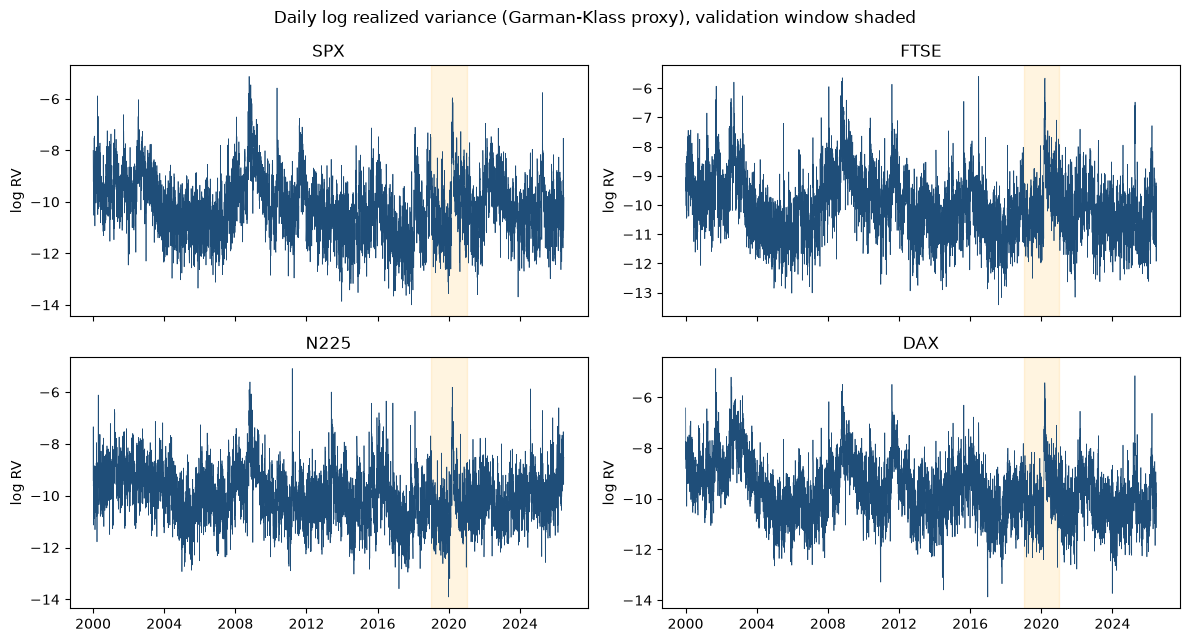

In [3]:
# Figure 1: log-RV time series per asset (val window 2019-2020 shaded; COVID stress lives here)
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharex=True)
for ax, (t, df) in zip(axes.ravel(), frames.items()):
    ax.plot(df['date'], df['log_rv'], lw=0.5, color='#1f4e79')
    ax.axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2020-12-31'), color='orange', alpha=0.12)
    ax.set_title(t); ax.set_ylabel('log RV')
fig.suptitle('Daily log realized variance (Garman-Klass proxy), validation window shaded')
fig.tight_layout()
fig.savefig(FIG / 'fig_logrv_series.svg'); fig.savefig(FIG / 'fig_logrv_series.pdf')
fig.savefig(FIG / 'fig_logrv_series.png', dpi=130)
plt.show()

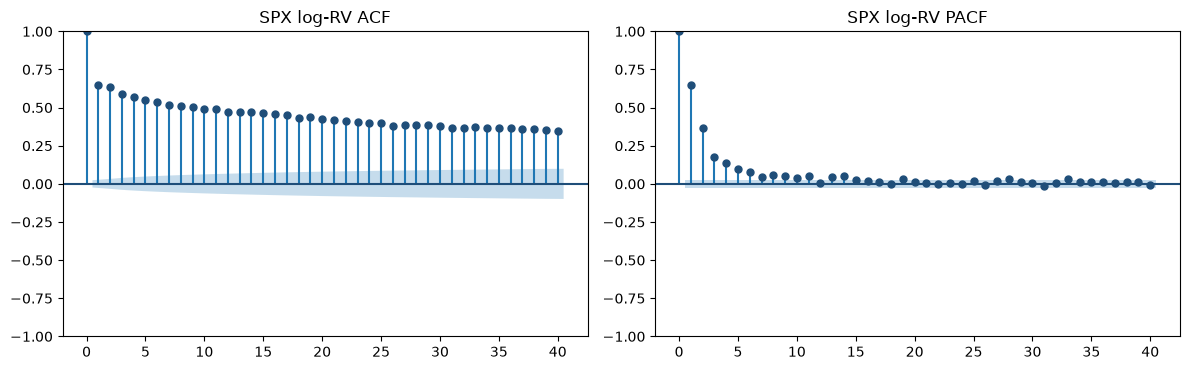

In [4]:
# Figure 2: ACF and PACF of SPX log-RV (long-memory signature motivating HAR-RV)
spx = frames['SPX']['log_rv'].dropna()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(spx, lags=40, ax=a1, color='#1f4e79')
plot_pacf(spx, lags=40, ax=a2, method='ywm', color='#1f4e79')
a1.set_title('SPX log-RV ACF'); a2.set_title('SPX log-RV PACF')
fig.tight_layout()
fig.savefig(FIG / 'fig_acf_pacf.svg'); fig.savefig(FIG / 'fig_acf_pacf.pdf')
fig.savefig(FIG / 'fig_acf_pacf.png', dpi=130)
plt.show()

The slow ACF decay with a sharp PACF cutoff is the long-memory persistence signature that the daily/weekly/monthly HAR-RV decomposition is designed to capture.